# Jupyter Notebook - Nome do Aluno

**Exercício 1 (Etapa 3):** Explorando as características financeiras do dataset.

*O que estou achando da atividade até aqui:* Estou aprendendo a identificar e organizar as colunas do dataset por categoria, o que facilita a análise posterior de cada grupo de características.

## Passo 1: Importando o pandas e carregando os dados

In [ ]:
import pandas as pd

df = pd.read_excel(
    'data/default_of_credit_card_clients__courseware_version_1_21_19.xls',
    header=0
)

## Exercício 1: Criando listas com os nomes das características financeiras

As características financeiras do dataset são divididas em dois grupos:

- **BILL_AMT1–6**: valor da fatura em cada um dos seis meses anteriores
- **PAY_AMT1–6**: valor do pagamento realizado em cada um dos seis meses anteriores

In [ ]:
bill_amt_features = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_features = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

In [ ]:
print('Características de valor de fatura:', bill_amt_features)
print('Características de valor de pagamento:', pay_amt_features)

## Exercício 2: Síntese estatística das características de valor da fatura

In [8]:
df[bill_amt_features].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,50646.744233,48624.349167,4.649736e+04,42791.362167,39884.398167,38480.350933
std,73376.695080,70893.963498,6.910251e+04,64090.316188,60606.644833,59406.836932
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3234.000000,2682.000000,2.403000e+03,2034.000000,1534.000000,1080.000000
50%,21644.500000,20597.000000,1.975250e+04,18759.500000,17835.500000,16643.000000
75%,66148.500000,62999.750000,5.952675e+04,53572.250000,49804.000000,48863.500000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


**Reflexão:** Sim, faz sentido. Os valores de fatura podem ser negativos quando há estornos ou créditos na conta, o que é comum em cartões de crédito. O que chama atenção é a diferença grande entre a mediana e a média — isso indica que a maioria dos clientes tem faturas relativamente baixas, mas alguns poucos com faturas muito altas acabam puxando a média para cima. Nada surpreendente para um dataset de cartão de crédito.

## Exercício 3: Histogramas das características de valor da fatura

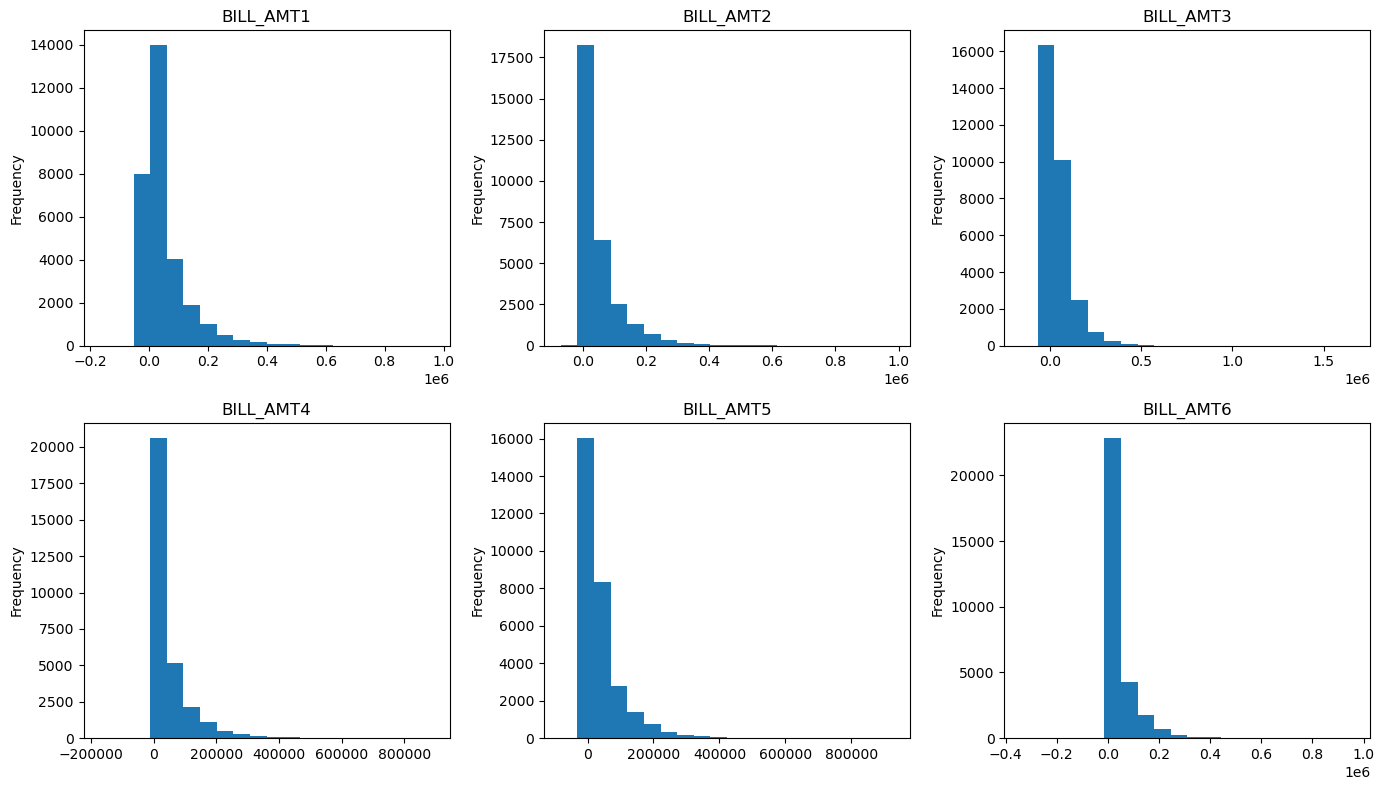

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, feature in zip(axes.flatten(), bill_amt_features):
    df[feature].plot.hist(ax=ax, bins=20)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

## Exercício 4: Resumo estatístico das características de valor do pagamento

In [27]:
df[pay_amt_features].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000
mean,5613.321500,5.855410e+03,5174.387967,4776.089733,4754.749200,5164.223267
std,16539.094312,2.299256e+04,17565.538305,15532.893047,15239.070708,17712.664703
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,836.000000,7.217500e+02,371.000000,223.000000,170.750000,9.000000
50%,2084.500000,2.000000e+03,1776.000000,1500.000000,1500.000000,1500.000000
75%,5000.000000,5.000000e+03,4500.000000,4000.000000,4000.000000,4000.000000
max,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000


**Reflexão:** Faz sentido. Ao contrário das faturas, os valores de pagamento não podem ser negativos — ninguém paga um valor negativo — e o mínimo de 0 indica clientes que não fizeram nenhum pagamento no mês. A diferença grande entre a mediana e a média, assim como o desvio padrão elevado, mostra que a maioria paga pouco enquanto alguns clientes fazem pagamentos muito altos.

## Exercício 5: Histogramas das características de valor do pagamento

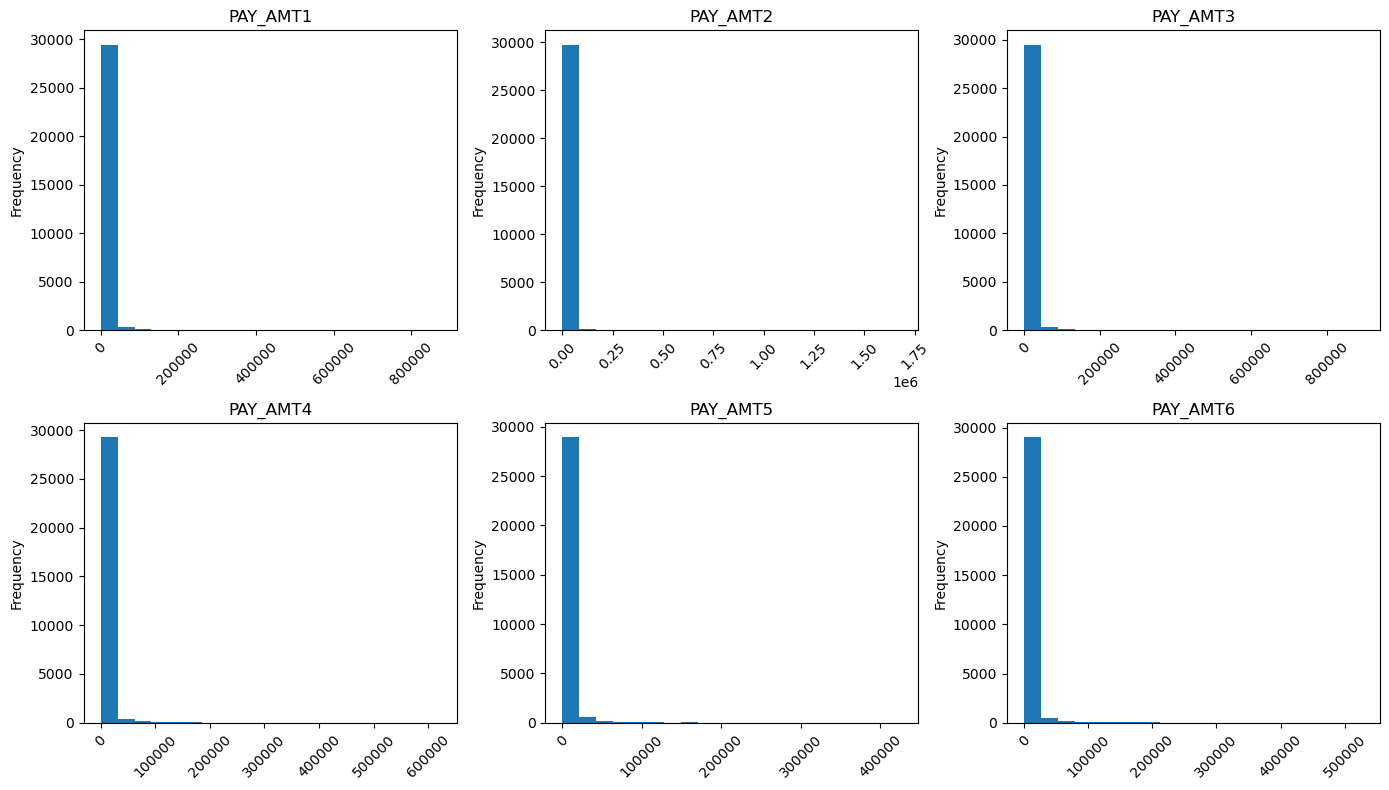

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, feature in zip(axes.flatten(), pay_amt_features):
    df[feature].plot.hist(ax=ax, bins=20)
    ax.set_title(feature)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Exercício 6: Contando pagamentos iguais a zero

In [28]:
zero_mask = df[pay_amt_features] == 0
zero_mask.sum()

PAY_AMT1    5504
PAY_AMT2    5663
PAY_AMT3    6223
PAY_AMT4    6660
PAY_AMT5    6955
PAY_AMT6    7416
dtype: int64

**Reflexão:** Faz sentido. O histograma já mostrava uma barra enorme no zero em todos os meses — uma grande parcela dos clientes simplesmente não fez pagamento naquele período. Isso confirma o que vimos no `.describe()`, onde o mínimo era 0 e a mediana era bem próxima de zero em várias colunas.

## Exercício 7: Histogramas com transformação logarítmica dos pagamentos diferentes de zero

In [ ]:
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, feature in zip(axes.flatten(), pay_amt_features):
    df[feature][~zero_mask[feature]].apply(np.log10).plot.hist(ax=ax, bins=20)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

**Reflexão:** Com a transformação logarítmica, os histogramas ficam muito mais legíveis e próximos de uma distribuição normal, o que é esperado para dados financeiros com forte assimetria. Sem o log, a barra do zero dominava o gráfico e escondia toda a variação dos demais valores. Ao excluir os zeros e aplicar o log10, conseguimos enxergar melhor como os pagamentos se distribuem entre os clientes que de fato pagaram algo.